In [2]:
import numpy as np
import h5py
import time
import inspect

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from helpers.gw_shapes import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from dataset_generation.noise_psd_gen import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, HDF5Glitch, Glitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
with h5py.File(glitch_ehm_dataset_path, "r") as h5:
    qt_ehm_array = h5["QT"][:]

with h5py.File(glitch_hm_dataset_path, "r") as h5:
    qt_hm_array = h5["QT"][:]

with h5py.File(glitch_lm_dataset_path, "r") as h5:
    qt_lm_array = h5["QT"][:]

In [3]:
snr_lm = np.max(qt_lm_array, axis=(1,2,3,4))
snr_hm = np.max(qt_hm_array, axis=(1,2,3,4))
snr_ehm = np.max(qt_ehm_array, axis=(1,2,3,4))

snrs = np.concatenate((snr_lm, snr_hm, snr_ehm))

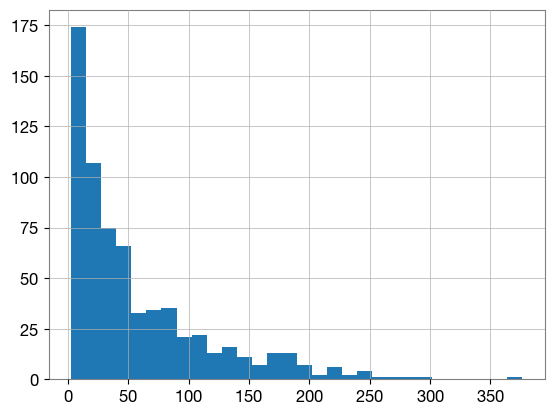

In [13]:
counts, bin_edges, _ =plt.hist(snr_lm, bins=30)
plt.show()

## Low mass GW

In [53]:
orbits_path2 = str(DIST / 'orbits' / 'orbits3.h5')
with h5py.File(orbits_path2, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

In [54]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 5.32e5, 'm2': 2.36e6, 'd': 3.48e3,
        'spin1': 0.93, 'spin2': 0.93, 't_inj': pipe['t_inj'], 'domain': 'freq',
        'gw_beta':-0.22*np.pi, 'gw_lambda':0.73*np.pi}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj'] - 0.47 * 3600, 'beta':4.32e1,
             'level':2*4.91e-13*4.32e1, 'inj_point':'tm_13'}]

run_simulation(
            gws, glitches, pipe,
            gw_path, None, orbits_path2,
            simulation_path,
            disable_noise=pipe['keep_noises']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [55]:
event = gws[0]
channel = 'T'
res = 256
spec = SPECS['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
t_arr, f_arr, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

0.19787907600402832


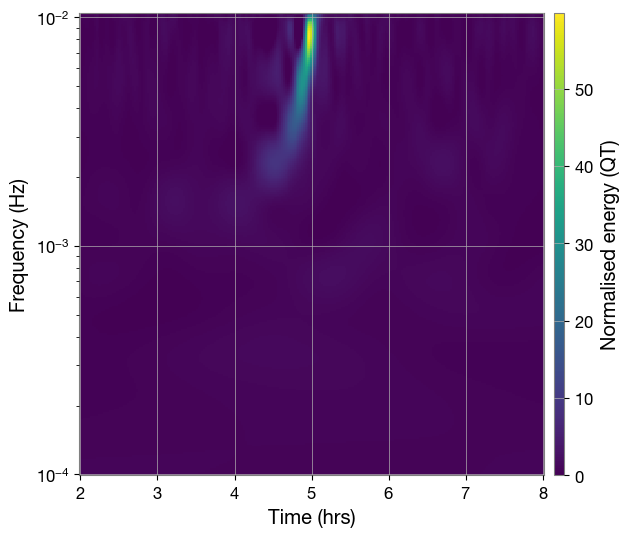

In [56]:
fig, axes = plt.subplots(1, 1, sharey=True, figsize=(6,6))

axes.pcolormesh(t_arr/3600, f_arr, QT, cmap='viridis')
axes.set_xlabel('Time (hrs)')
axes.set_ylabel('Frequency (Hz)')
axes.set_yscale('log')
axes.colorbar(label='Normalised energy (QT)')
plt.show()

## Q transform with phase

In [3]:
def q_transform_phase(times, signal, Q, frange, trange, resolution):
    
    f_arr, t_arr = generate_ft_arr(frange, trange, Q)

    QTnew = []
    for i, f in enumerate(f_arr):
        t_slice = t_arr[i]
        out_slice_real, out_slice_imag = [], []
        for t in t_slice:
            tau = Q/(np.sqrt(2)*np.pi*f)
            
            seg = np.where((times > t - 4*tau) & (times < t + 4*tau))[0]
            timeseg = times[seg]
            sigseg = signal[seg]
            sigseg = sigseg*np.hanning(len(sigseg))
            
            window = np.exp(-0.5 * ((timeseg-t)/tau)**2) * np.exp(-2j*np.pi*f*(timeseg-t))
            window /= np.sqrt(np.sum(np.abs(window)**2))
            out_slice_real.append(np.sum(sigseg * window))
        try:
            F = interp1d(t_slice, out_slice_real, kind='cubic', fill_value='extrapolate')
        except:
            F = interp1d(t_slice, out_slice_real, kind='linear', fill_value='extrapolate')
        QTnew.append(F(t_arr[-1]))

    QTnew = np.array(QTnew)
    
    f_new = np.logspace(np.log10(np.min(f_arr)), np.log10(np.max(f_arr)), resolution, endpoint=True)
    t_new = np.linspace(np.min(t_arr[-1]), np.max(t_arr[-1]), resolution, endpoint=True)
    
    Z_real = np.real(QTnew)
    Z_imag = np.imag(QTnew)

    spline_real = RectBivariateSpline(f_arr, t_arr[-1], Z_real)
    spline_imag = RectBivariateSpline(f_arr, t_arr[-1], Z_imag)

    QT_real_new = spline_real(f_new, t_new)
    QT_imag_new = spline_imag(f_new, t_new)

    QTnew = QT_real_new + 1j * QT_imag_new

    #QTnew_real = np.clip(QTnew_real, 1e-12, None)

    return t_new, f_new, QTnew

def generate_qscan_phase(tdi_dict, channel, pipe, event, 
                   frange, trange, Q, resolution):

    signal = TimeSeries(tdi_dict[channel], dt=pipe['dt'], t0=0)
    
    time_secs = signal.times.value
    time_hrs = time_secs/3600
    tevent = event['t_inj']
    
    index = np.where((time_hrs <= tevent/3600 + trange[1]) & (time_hrs >= tevent/3600 + trange[0]))[0]
    sigslice = signal[index].value
    timeslice = signal[index].times.value
    
    t_arr, f_arr, QT = q_transform_phase(timeslice, sigslice, Q=Q, resolution=resolution,
                        frange=frange, trange=(np.min(timeslice),np.max(timeslice)))

    return t_arr, f_arr, QT


In [4]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 1e5, 'm2': 1e5, 'd': 1e4,
        'spin1': 0, 'spin2': 0, 't_inj': PIPE['t_inj'], 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]
glitches = []

run_simulation(
            gws, glitches, PIPE,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=PIPE['keep_noises'],
            seed=42
        )
raw_dict = run_tdi(simulation_path, PIPE)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [5]:
event = gws[0]
channel = 'A'
res = 256
spec = SPECS['high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
t_arr, f_arr, QT = generate_qscan(tdi_dict, channel, PIPE, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
t_arr, f_arr, QT_phase = generate_qscan_phase(tdi_dict, channel, PIPE, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

1.489757776260376


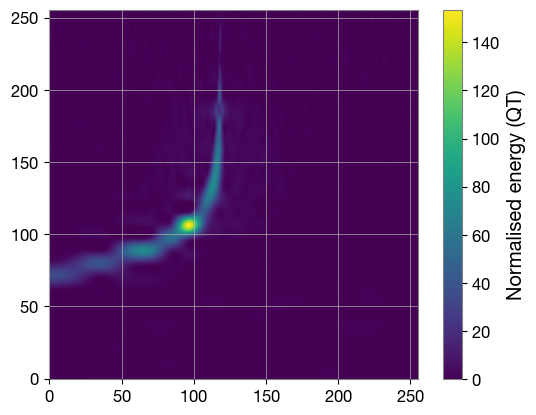

In [6]:
plt.imshow(QT, origin='lower')
plt.colorbar(label='Normalised energy (QT)')
plt.show()

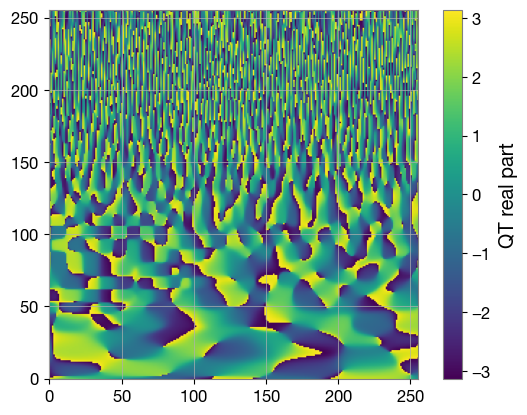

In [9]:
plt.imshow(np.angle(QT_phase), origin='lower')
plt.colorbar(label='QT real part')
plt.show()

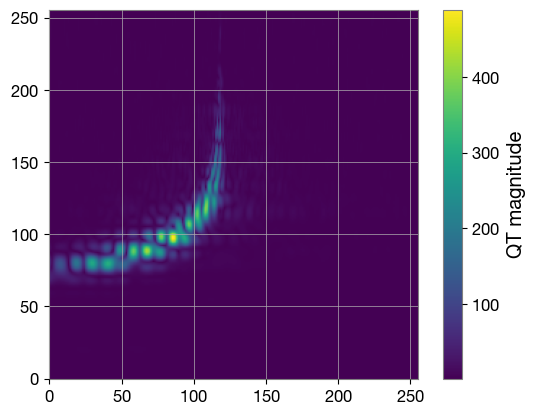

In [130]:
arr = np.sqrt(QT_phase[:,:,0]**2 + QT_phase[:,:,1]**2)
plt.imshow(arr, origin='lower')
plt.colorbar(label='QT magnitude')
plt.show()

In [61]:
from model_training.model import LISADataset
from torch.utils.data import random_split, DataLoader, Subset

dataset = LISADataset(training_lm_dataset_path)

In [62]:
unique_indices = np.unique(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_indices = unique_indices[:n_train]
val_indices   = unique_indices[n_train:n_train+n_val]
test_indices  = unique_indices[n_train+n_val:]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)